# 01 - EDA and Hypothesis Tests

Interactive notebook for exploratory checks and statistical testing.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

PROJECT_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data_preprocessing import load_data, basic_checks, handle_missing_values
from src.utils import TARGET_COLUMN, DIGITAL_DISTRACTION_FEATURES, OUTPUT_DIR

print('Project root:', PROJECT_ROOT)

Project root: /Users/uygararas/Desktop/yaren/dsa210-project-iclalyarenhasaltin


In [2]:
df, is_synthetic = load_data(project_root=PROJECT_ROOT)
print('Synthetic data used:' , is_synthetic)
basic_checks(df)
df = handle_missing_values(df, strategy='drop')
df.shape

Synthetic data used: True
Dataset shape: (500, 18)
Column names: ['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']
Data types:
 student_id                   str
age                        int64
gender                       str
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level             float64
focus_score              float64
final_grade              float64
productivity_score       float64
dtype:

/Users/uygararas/Desktop/yaren/dsa210-project-iclalyarenhasaltin/src/data_preprocessing.py:91: UserWarning: Data file not found at /Users/uygararas/Desktop/yaren/dsa210-project-iclalyarenhasaltin/student_productivity.csv. Using synthetic data for demonstration.
  warnings.warn(


(500, 18)

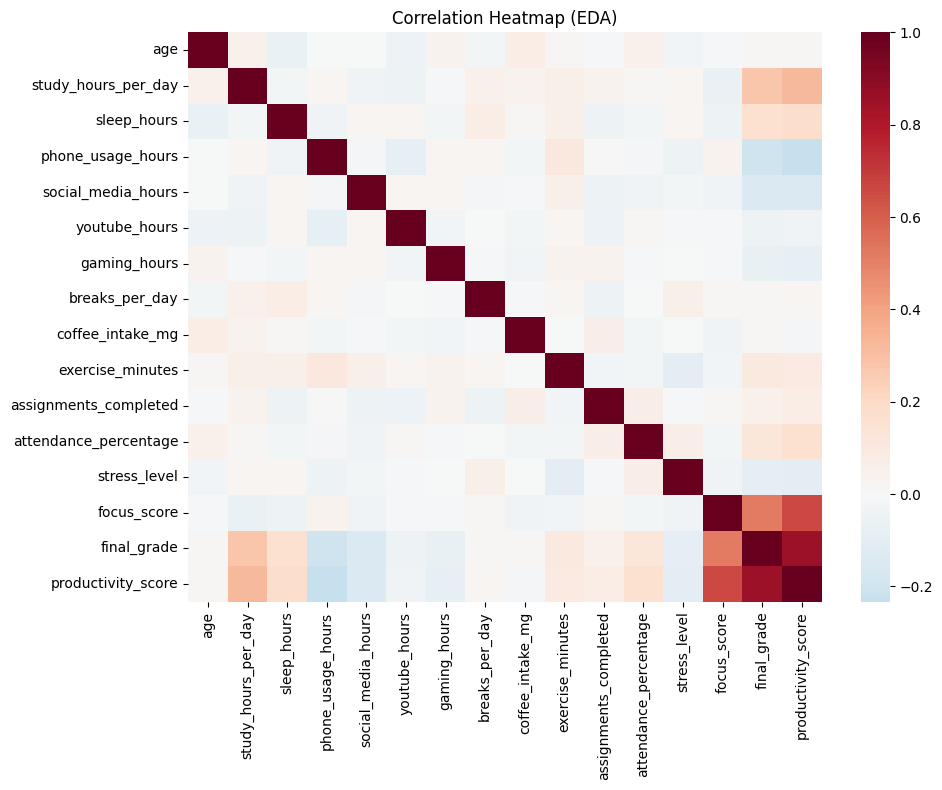

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap (EDA)')
plt.tight_layout()
plt.show()

In [4]:
test_cols = [
    'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours',
    'study_hours_per_day', 'sleep_hours', 'exercise_minutes', 'focus_score'
]
rows = []
for col in test_cols:
    if col in df.columns:
        x = df[col].values
        y = df[TARGET_COLUMN].values
        pr, pp = pearsonr(x, y)
        sr, sp = spearmanr(x, y)
        rows.append({
            'feature': col,
            'pearson_r': pr,
            'pearson_p': pp,
            'spearman_rho': sr,
            'spearman_p': sp,
        })

hypothesis_df = pd.DataFrame(rows).sort_values('pearson_p')
hypothesis_df

,feature,pearson_r,pearson_p,spearman_rho,spearman_p
7,focus_score,0.657605,3.033871e-63,0.664586,5.063108e-65
4,study_hours_per_day,0.329326,4.113328e-14,0.322538,1.439869e-13
0,phone_usage_hours,-0.233183,1.335108e-07,-0.207625,2.839058e-06
5,sleep_hours,0.172134,1.095929e-04,0.151525,6.753963e-04
1,social_media_hours,-0.153777,5.595698e-04,-0.129618,3.691845e-03
6,exercise_minutes,0.093911,3.579095e-02,0.084905,5.780119e-02
3,gaming_hours,-0.087347,5.094031e-02,-0.079766,7.474786e-02
2,youtube_hours,-0.041063,3.595218e-01,-0.040842,3.621119e-01


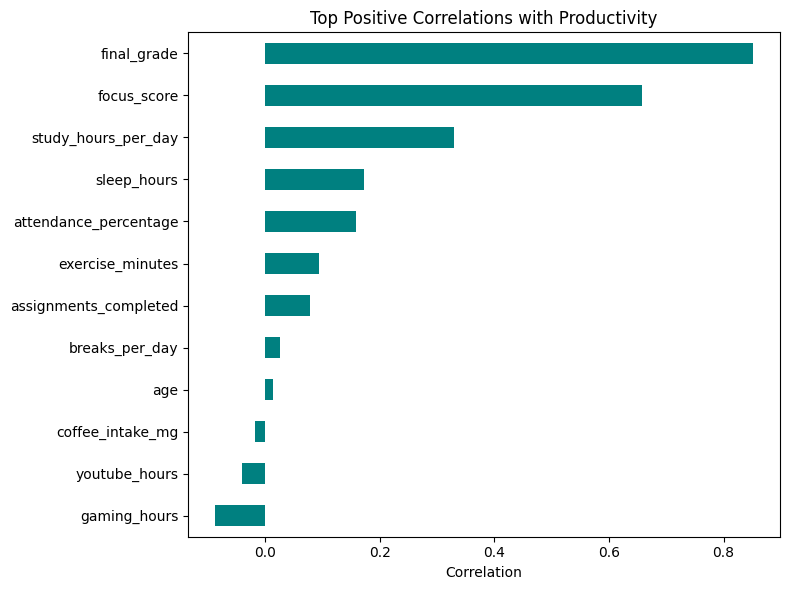

In [5]:
top = corr[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values()
plt.figure(figsize=(8, 6))
top.tail(12).plot(kind='barh', color='teal')
plt.title('Top Positive Correlations with Productivity')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

## Extra EDA checks (more detailed)

Below cells are intentionally more exploratory, for understanding what can go wrong later in modeling.

In [6]:
# 1) quick data quality profile
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(2),
    'n_unique': df.nunique()
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, True])
quality.head(20)

,dtype,missing_count,missing_pct,n_unique
gender,str,0,0.0,2
breaks_per_day,int64,0,0.0,10
age,int64,0,0.0,12
assignments_completed,int64,0,0.0,20
exercise_minutes,int64,0,0.0,40
coffee_intake_mg,int64,0,0.0,282
productivity_score,float64,0,0.0,432
attendance_percentage,float64,0,0.0,462
stress_level,float64,0,0.0,483
study_hours_per_day,float64,0,0.0,492


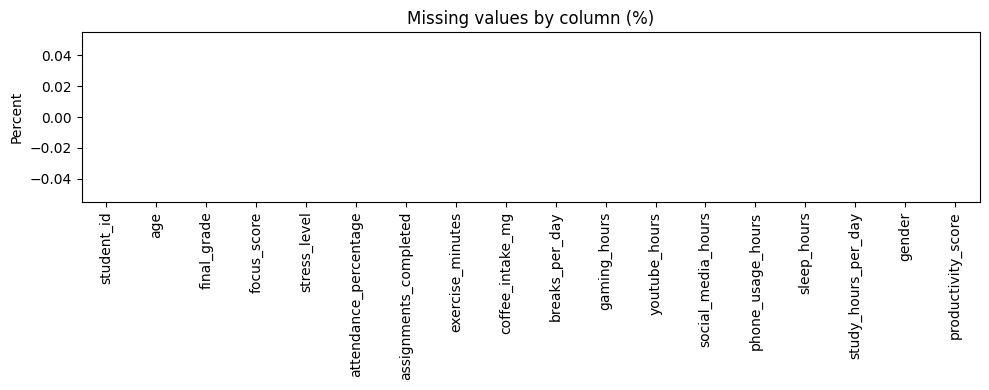

In [7]:
# 2) missing value profile chart
miss = (df.isnull().mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
miss.plot(kind='bar', color='gray')
plt.title('Missing values by column (%)')
plt.ylabel('Percent')
plt.tight_layout()
plt.show()

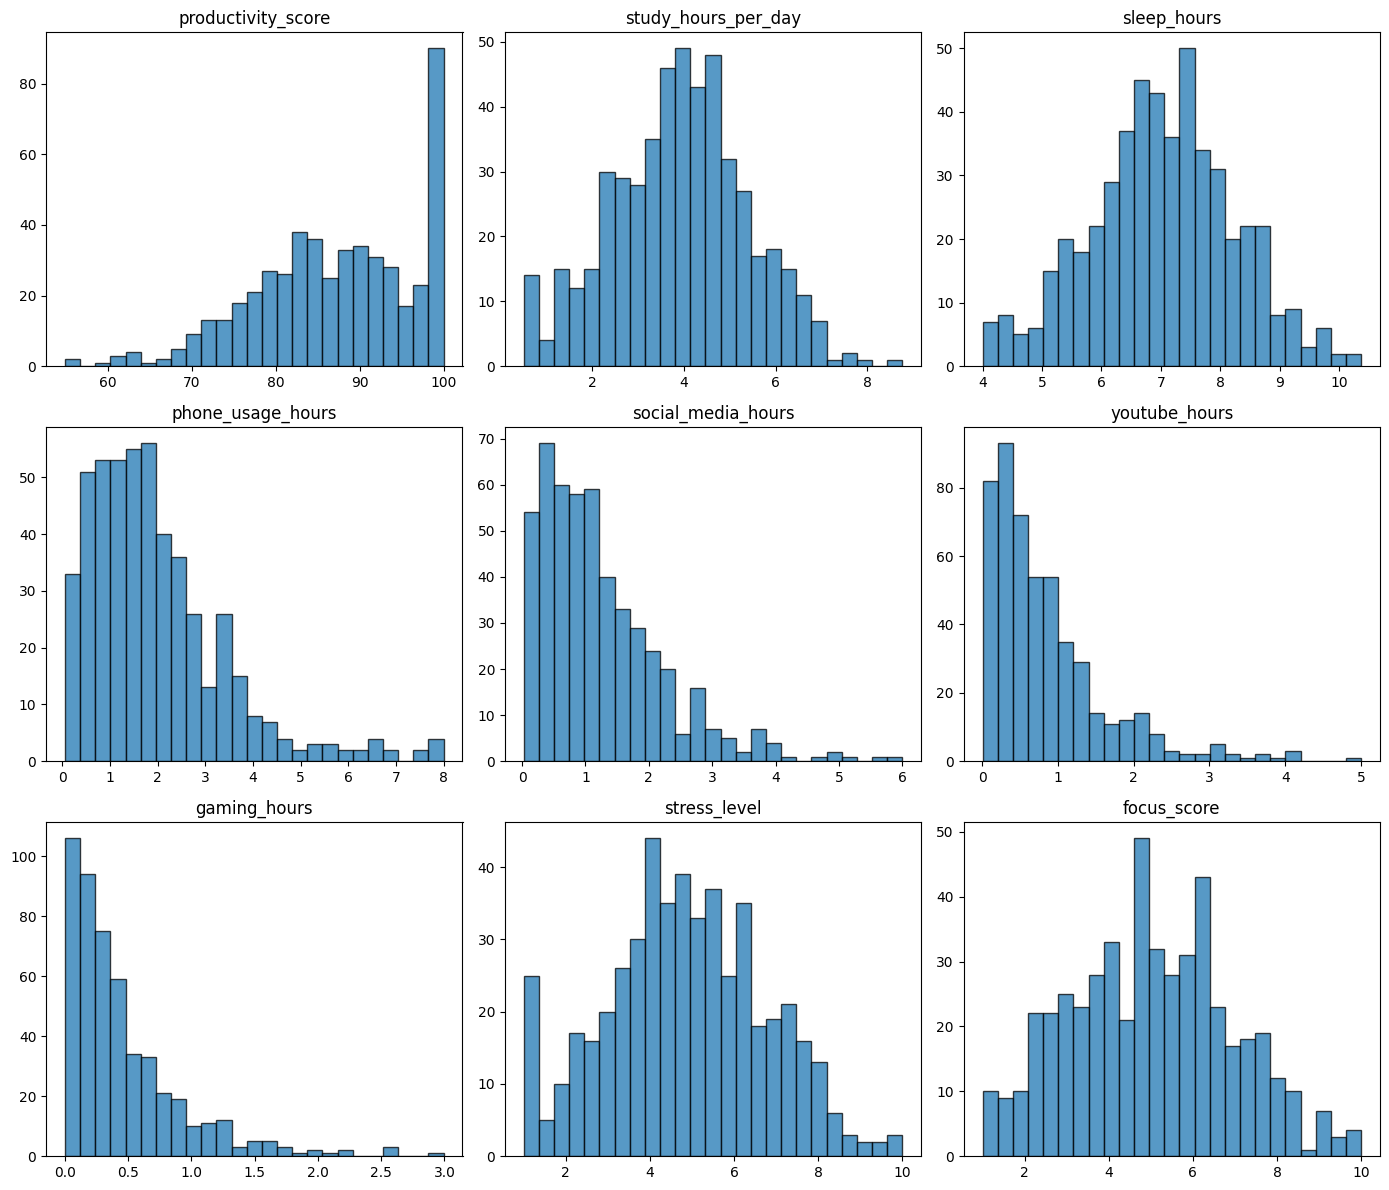

In [8]:
# 3) key distributions in one place
key = [
    'productivity_score', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours',
    'social_media_hours', 'youtube_hours', 'gaming_hours', 'stress_level', 'focus_score'
]
key = [c for c in key if c in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(key) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(key):
    axes[i].hist(df[col].dropna(), bins=25, edgecolor='black', alpha=0.75)
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
# 4) outlier preview by IQR
outlier_rows = []
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET_COLUMN]
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = int(((df[col] < low) | (df[col] > high)).sum())
    outlier_rows.append({'feature': col, 'outlier_count': n_out, 'outlier_pct': 100 * n_out / len(df)})

outlier_df = pd.DataFrame(outlier_rows).sort_values('outlier_count', ascending=False)
outlier_df.head(15)

,feature,outlier_count,outlier_pct
6,gaming_hours,26,5.2
5,youtube_hours,24,4.8
3,phone_usage_hours,22,4.4
4,social_media_hours,19,3.8
9,exercise_minutes,8,1.6
14,final_grade,4,0.8
12,stress_level,3,0.6
1,study_hours_per_day,2,0.4
2,sleep_hours,2,0.4
11,attendance_percentage,2,0.4


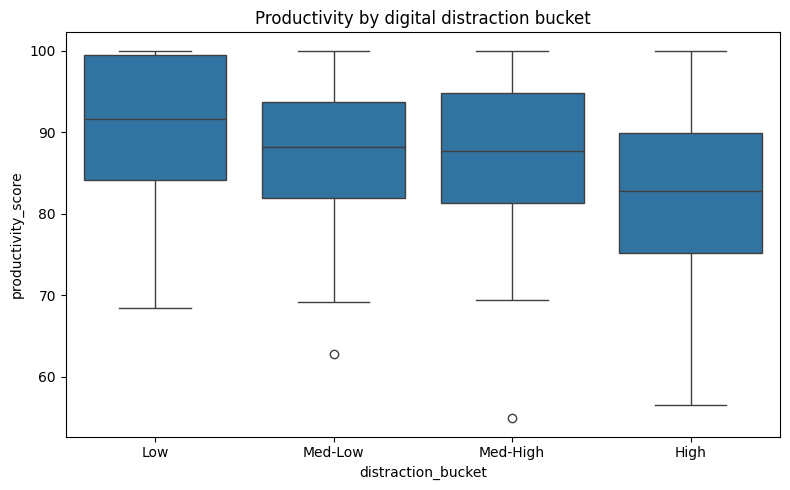

In [10]:
# 5) distraction vs productivity (bucket view)
if set(DIGITAL_DISTRACTION_FEATURES).issubset(df.columns):
    tmp = df.copy()
    tmp['digital_distraction_score'] = tmp[DIGITAL_DISTRACTION_FEATURES].sum(axis=1)
    tmp['distraction_bucket'] = pd.qcut(
        tmp['digital_distraction_score'],
        q=4,
        labels=['Low', 'Med-Low', 'Med-High', 'High']
    )

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=tmp, x='distraction_bucket', y=TARGET_COLUMN)
    plt.title('Productivity by digital distraction bucket')
    plt.tight_layout()
    plt.show()

    tmp.groupby('distraction_bucket')[TARGET_COLUMN].describe()[['mean', 'std', 'min', 'max']]

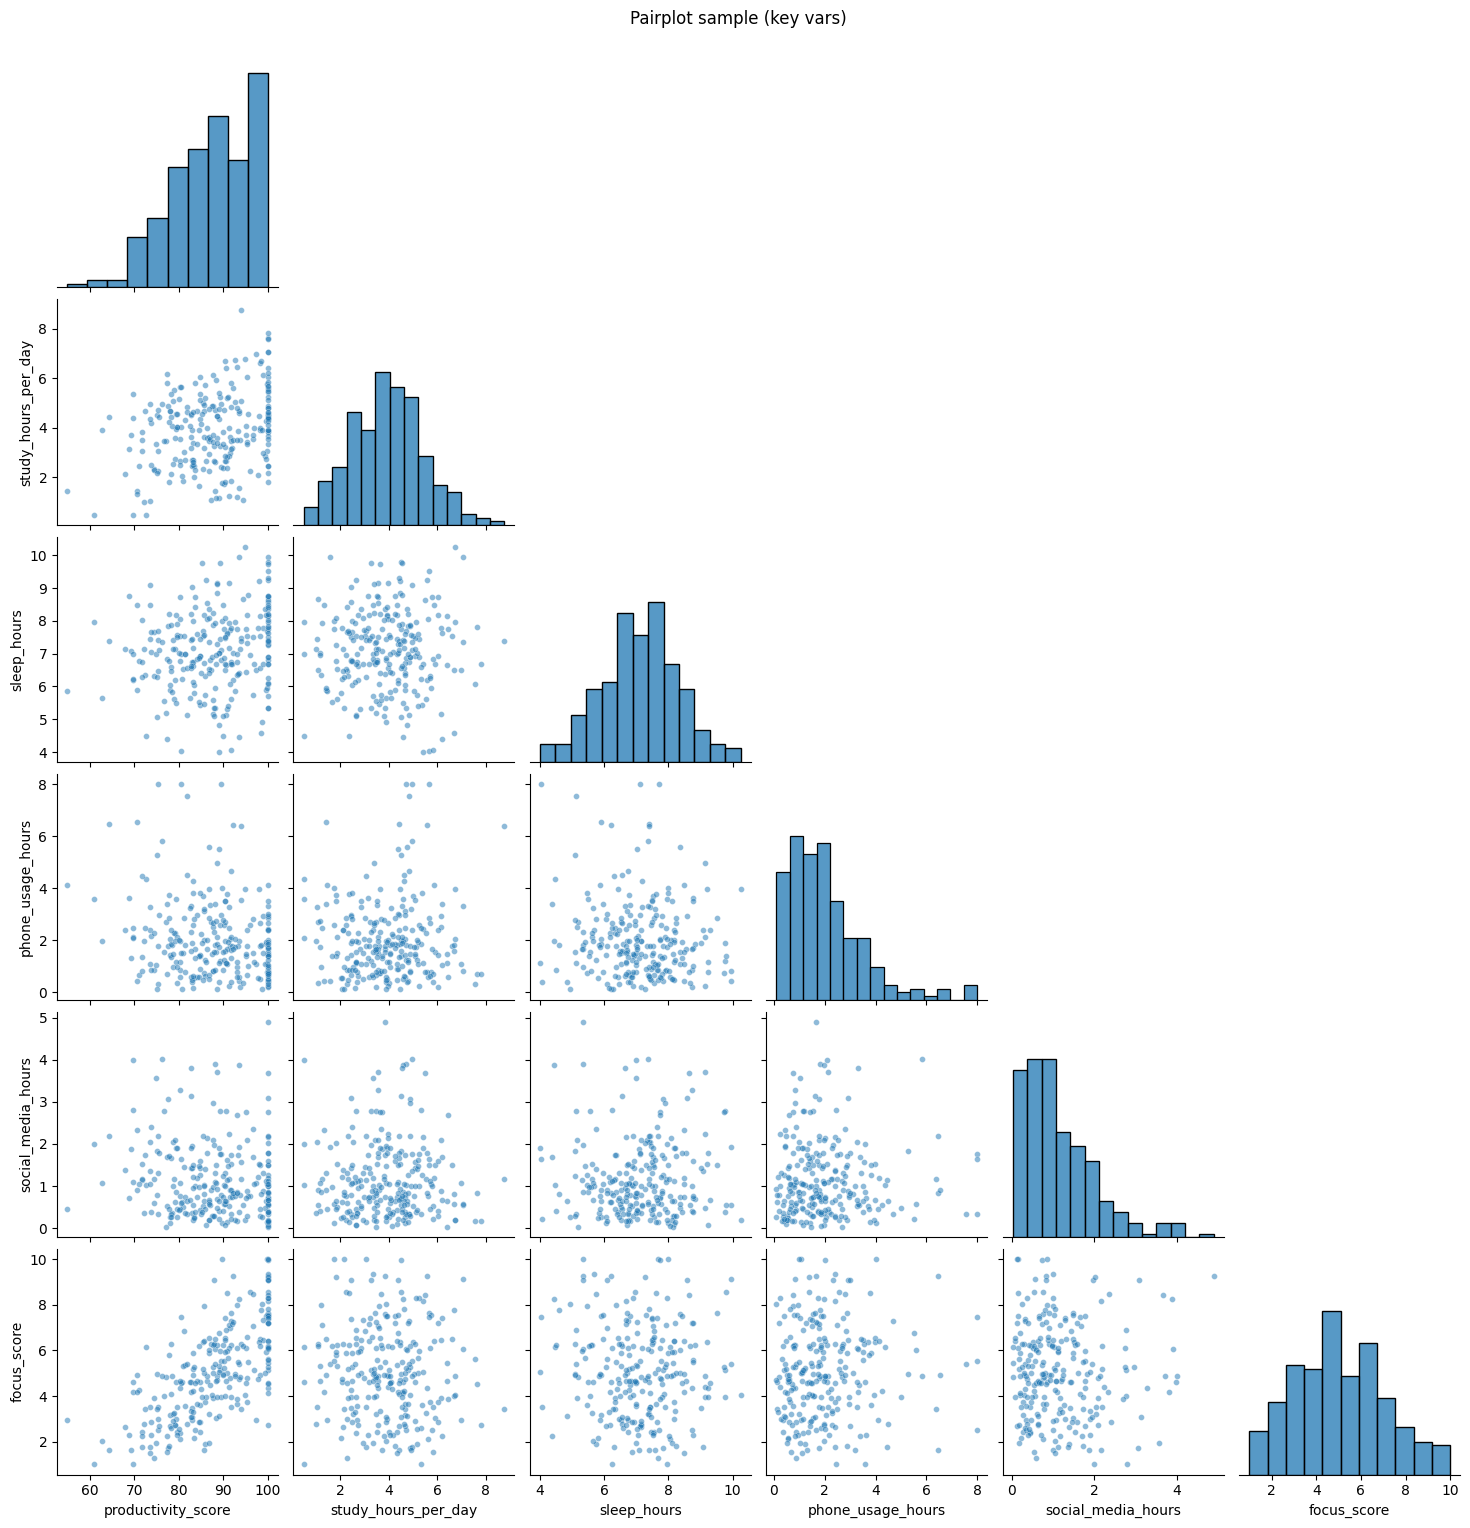

In [11]:
# 6) pairplot sample (small sample so notebook dont explode)
pair_cols = [
    TARGET_COLUMN, 'study_hours_per_day', 'sleep_hours',
    'phone_usage_hours', 'social_media_hours', 'focus_score'
]
pair_cols = [c for c in pair_cols if c in df.columns]
if len(pair_cols) >= 3:
    sample_n = min(250, len(df))
    pair_df = df[pair_cols].sample(sample_n, random_state=42)
    g = sns.pairplot(pair_df, corner=True, plot_kws={'alpha': 0.5, 's': 18})
    g.fig.suptitle('Pairplot sample (key vars)', y=1.02)
    plt.show()

In [12]:
# 7) extra hypothesis test style checks (split-based)
# Not causal proof, just statistical difference checks.
from scipy.stats import ttest_ind

if 'gender' in df.columns:
    gvals = df['gender'].astype(str).str.title()
    groups = [x for x in gvals.unique() if x == x]
    if len(groups) >= 2:
        g1 = df.loc[gvals == groups[0], TARGET_COLUMN].dropna()
        g2 = df.loc[gvals == groups[1], TARGET_COLUMN].dropna()
        stat, p = ttest_ind(g1, g2, equal_var=False)
        print(f't-test productivity by gender: {groups[0]} vs {groups[1]} -> t={stat:.3f}, p={p:.4g}')

if set(DIGITAL_DISTRACTION_FEATURES).issubset(df.columns):
    score = df[DIGITAL_DISTRACTION_FEATURES].sum(axis=1)
    q1 = score.quantile(0.25)
    q3 = score.quantile(0.75)
    low = df.loc[score <= q1, TARGET_COLUMN].dropna()
    high = df.loc[score >= q3, TARGET_COLUMN].dropna()
    stat, p = ttest_ind(low, high, equal_var=False)
    print(f't-test low vs high distraction quartiles -> t={stat:.3f}, p={p:.4g}')

t-test productivity by gender: Male vs Female -> t=0.561, p=0.5753
t-test low vs high distraction quartiles -> t=6.107, p=4.134e-09


In [13]:
# 8) save key test table for report drafting
hypothesis_df.to_csv(os.path.join(PROJECT_ROOT, 'outputs', 'notebook_hypothesis_tests.csv'), index=False)

## Deeper EDA blocks

These are extra analysis blocks for catching potential issues before modeling.

In [14]:
# helpers for saving notebook plots/tables
NB_OUT = os.path.join(PROJECT_ROOT, 'outputs')
os.makedirs(NB_OUT, exist_ok=True)

sns.set_theme(style='whitegrid')


def nb_savefig(name):
    path = os.path.join(NB_OUT, name)
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches='tight')


def display_head(df_like, n=10):
    return df_like.head(n) if hasattr(df_like, 'head') else df_like

In [15]:
# 9) distribution shape stats (mean, std, skew, kurtosis)
num = df.select_dtypes(include=[np.number]).copy()
shape_stats = pd.DataFrame({
    'mean': num.mean(),
    'std': num.std(),
    'skew': num.skew(),
    'kurtosis': num.kurt()
}).sort_values('skew', key=lambda s: s.abs(), ascending=False)

shape_stats.to_csv(os.path.join(NB_OUT, 'notebook_distribution_shape_stats.csv'))
display_head(shape_stats, 20)

,mean,std,skew,kurtosis
gaming_hours,0.457292,0.458904,2.028587,5.337553
youtube_hours,0.835317,0.775313,1.881671,4.438042
phone_usage_hours,1.973868,1.457966,1.573504,3.240789
social_media_hours,1.243373,0.975056,1.487955,2.905175
productivity_score,87.094334,9.614972,-0.468249,-0.266838
final_grade,78.252324,10.212838,-0.450137,0.267735
exercise_minutes,30.156000,6.721162,0.303752,0.143120
attendance_percentage,85.002687,9.243709,-0.200091,-0.400524
focus_score,5.001221,1.927486,0.143656,-0.458727
sleep_hours,7.022841,1.222323,-0.068245,-0.157812


In [16]:
# 10) rank correlations with target (both pearson and spearman)
rows = []
for col in num.columns:
    if col == TARGET_COLUMN:
        continue
    p_r, p_p = pearsonr(df[col], df[TARGET_COLUMN])
    s_r, s_p = spearmanr(df[col], df[TARGET_COLUMN])
    rows.append({
        'feature': col,
        'pearson_r': p_r,
        'pearson_p': p_p,
        'spearman_rho': s_r,
        'spearman_p': s_p,
    })

corr_tests = pd.DataFrame(rows).sort_values('pearson_p')
corr_tests.to_csv(os.path.join(NB_OUT, 'notebook_corr_tests_full.csv'), index=False)
display_head(corr_tests, 20)

,feature,pearson_r,pearson_p,spearman_rho,spearman_p
14,final_grade,0.851598,8.520559e-142,0.848265,1.377189e-139
13,focus_score,0.657605,3.033871e-63,0.664586,5.063108e-65
1,study_hours_per_day,0.329326,4.113328e-14,0.322538,1.439869e-13
3,phone_usage_hours,-0.233183,1.335108e-07,-0.207625,2.839058e-06
2,sleep_hours,0.172134,1.095929e-04,0.151525,6.753963e-04
11,attendance_percentage,0.158052,3.887058e-04,0.133284,2.824711e-03
4,social_media_hours,-0.153777,5.595698e-04,-0.129618,3.691845e-03
12,stress_level,-0.104824,1.905126e-02,-0.110315,1.358381e-02
9,exercise_minutes,0.093911,3.579095e-02,0.084905,5.780119e-02
6,gaming_hours,-0.087347,5.094031e-02,-0.079766,7.474786e-02


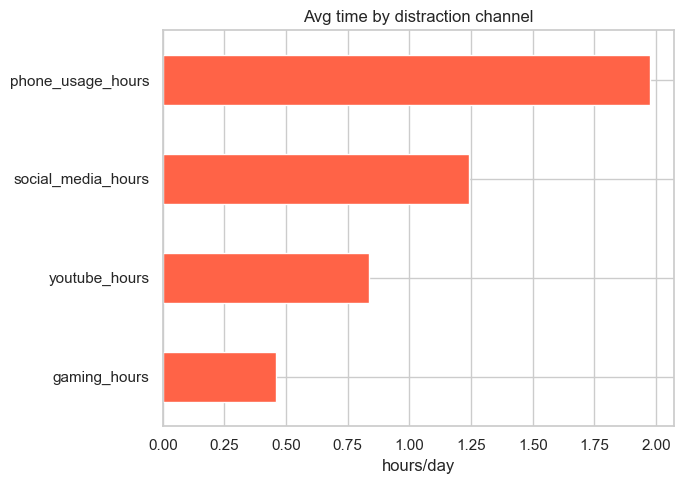

In [17]:
# 11) stacked distraction composition stats
dist_cols = [c for c in DIGITAL_DISTRACTION_FEATURES if c in df.columns]
if dist_cols:
    dist_stats = df[dist_cols].describe().T[['mean', 'std', 'min', 'max']]
    dist_stats.to_csv(os.path.join(NB_OUT, 'notebook_distraction_stats.csv'))

    plt.figure(figsize=(7, 5))
    dist_stats['mean'].sort_values().plot(kind='barh', color='tomato')
    plt.title('Avg time by distraction channel')
    plt.xlabel('hours/day')
    nb_savefig('notebook_distraction_avg_bar.png')
    plt.show()

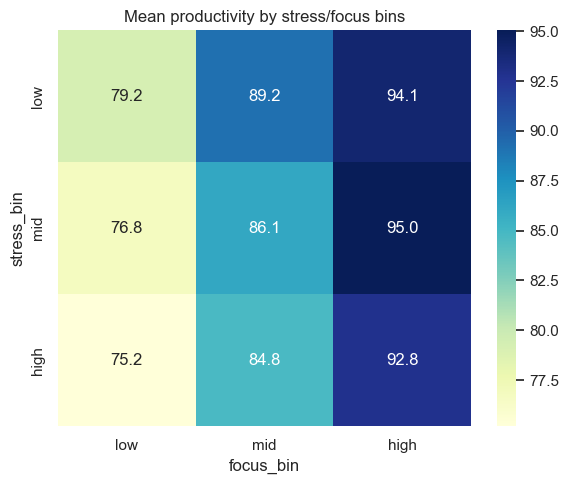

In [18]:
# 12) productivity across stress and focus bins
if 'stress_level' in df.columns and 'focus_score' in df.columns:
    tmp = df.copy()
    tmp['stress_bin'] = pd.cut(tmp['stress_level'], bins=[0, 3, 6, 10], labels=['low', 'mid', 'high'])
    tmp['focus_bin'] = pd.cut(tmp['focus_score'], bins=[0, 3, 6, 10], labels=['low', 'mid', 'high'])

    pivot = tmp.pivot_table(index='stress_bin', columns='focus_bin', values=TARGET_COLUMN, aggfunc='mean')
    pivot.to_csv(os.path.join(NB_OUT, 'notebook_stress_focus_pivot.csv'))

    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title('Mean productivity by stress/focus bins')
    nb_savefig('notebook_stress_focus_heatmap.png')
    plt.show()
    pivot

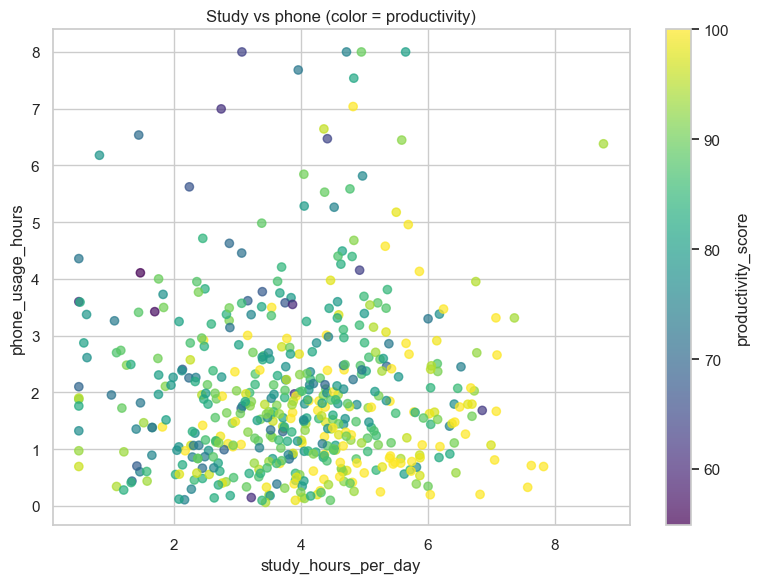

In [19]:
# 13) interaction scatter: study x phone vs productivity
if 'study_hours_per_day' in df.columns and 'phone_usage_hours' in df.columns:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        df['study_hours_per_day'],
        df['phone_usage_hours'],
        c=df[TARGET_COLUMN],
        cmap='viridis',
        alpha=0.7
    )
    plt.colorbar(sc, label='productivity_score')
    plt.xlabel('study_hours_per_day')
    plt.ylabel('phone_usage_hours')
    plt.title('Study vs phone (color = productivity)')
    nb_savefig('notebook_study_phone_interaction.png')
    plt.show()

In [20]:
# 14) low/high productivity profile compare
q_low = df[TARGET_COLUMN].quantile(0.25)
q_high = df[TARGET_COLUMN].quantile(0.75)
low_grp = df[df[TARGET_COLUMN] <= q_low]
high_grp = df[df[TARGET_COLUMN] >= q_high]

compare_cols = [
    'study_hours_per_day', 'sleep_hours', 'exercise_minutes',
    'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours',
    'stress_level', 'focus_score', 'attendance_percentage'
]
compare_cols = [c for c in compare_cols if c in df.columns]

profile = pd.DataFrame({
    'low_productivity_mean': low_grp[compare_cols].mean(),
    'high_productivity_mean': high_grp[compare_cols].mean(),
})
profile['delta_high_minus_low'] = profile['high_productivity_mean'] - profile['low_productivity_mean']
profile = profile.sort_values('delta_high_minus_low', ascending=False)
profile.to_csv(os.path.join(NB_OUT, 'notebook_low_high_profile.csv'))
profile

,low_productivity_mean,high_productivity_mean,delta_high_minus_low
attendance_percentage,83.659786,87.204122,3.544336
focus_score,3.275826,6.644016,3.368190
exercise_minutes,28.984000,30.824000,1.840000
study_hours_per_day,3.393277,4.643823,1.250546
sleep_hours,6.804039,7.373570,0.569530
gaming_hours,0.501342,0.415829,-0.085513
youtube_hours,0.836597,0.740661,-0.095936
social_media_hours,1.429813,1.081269,-0.348544
stress_level,5.173782,4.658907,-0.514875
phone_usage_hours,2.389428,1.625257,-0.764171


In [21]:
# 15) quick multicollinearity check (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [
    'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours',
    'youtube_hours', 'gaming_hours', 'exercise_minutes', 'stress_level', 'focus_score'
]
vif_cols = [c for c in vif_cols if c in df.columns]

if len(vif_cols) >= 3:
    X_vif = df[vif_cols].dropna().copy()
    # avoid zero variance edge case
    X_vif = X_vif.loc[:, X_vif.nunique() > 1]
    vif_table = pd.DataFrame({
        'feature': X_vif.columns,
        'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    }).sort_values('VIF', ascending=False)
    vif_table.to_csv(os.path.join(NB_OUT, 'notebook_vif_table.csv'), index=False)
    vif_table.head(20)

In [22]:
# 16) bootstrap CI for productivity by distraction bucket
if set(DIGITAL_DISTRACTION_FEATURES).issubset(df.columns):
    tmp = df.copy()
    tmp['digital_distraction_score'] = tmp[DIGITAL_DISTRACTION_FEATURES].sum(axis=1)
    tmp['distraction_bucket'] = pd.qcut(tmp['digital_distraction_score'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])

    rng = np.random.default_rng(42)
    rows = []
    for b, grp in tmp.groupby('distraction_bucket'):
        vals = grp[TARGET_COLUMN].dropna().values
        if len(vals) == 0:
            continue
        boots = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(1000)]
        rows.append({
            'bucket': str(b),
            'mean': np.mean(vals),
            'ci_low_95': np.percentile(boots, 2.5),
            'ci_high_95': np.percentile(boots, 97.5),
            'n': len(vals)
        })

    ci_df = pd.DataFrame(rows)
    ci_df.to_csv(os.path.join(NB_OUT, 'notebook_distraction_bucket_bootstrap_ci.csv'), index=False)
    ci_df

In [23]:
# 17) check possible leakage-ish links
leak_cols = [c for c in ['final_grade', 'focus_score', 'attendance_percentage'] if c in df.columns]
if leak_cols:
    leak_corr = df[leak_cols + [TARGET_COLUMN]].corr()[TARGET_COLUMN].sort_values(ascending=False)
    leak_corr.to_csv(os.path.join(NB_OUT, 'notebook_possible_leakage_corr.csv'))
    leak_corr

In [24]:
# 18) optional normality check for target
from scipy.stats import shapiro

y = df[TARGET_COLUMN].dropna().values
sample_for_test = y if len(y) <= 5000 else y[:5000]
stat, p = shapiro(sample_for_test)
print(f'Shapiro test for target: W={stat:.4f}, p={p:.4g}')
print('Note: with larger n, tiny deviations can become significant.')

Shapiro test for target: W=0.9544, p=2.639e-11
Note: with larger n, tiny deviations can become significant.


In [25]:
# 19) save a compact markdown summary for report drafts
summary_lines = []
summary_lines.append('# Notebook EDA Summary')
summary_lines.append('')
summary_lines.append(f'- rows: {len(df)}')
summary_lines.append(f'- cols: {df.shape[1]}')
summary_lines.append(f'- target mean: {df[TARGET_COLUMN].mean():.3f}')
summary_lines.append('')

if 'corr_tests' in globals() and len(corr_tests) > 0:
    top5 = corr_tests.sort_values('pearson_p').head(5)
    summary_lines.append('## Most significant (Pearson p)')
    for _, r in top5.iterrows():
        summary_lines.append(
            f"- {r['feature']}: r={r['pearson_r']:+.3f}, p={r['pearson_p']:.4g}"
        )

summary_md_path = os.path.join(NB_OUT, 'notebook_eda_summary.md')
with open(summary_md_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines))